## ======================
#  Data Exploration
## ======================


## Import Libraries

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.tokenize import word_tokenize
import nltk

from gensim.models import Word2Vec
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

## Load Dataset

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Users\saket\Downloads\twitter_disaster (1).csv")
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
df.tail()

,id,keyword,location,text,target
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1
7612,10873,NaN,NaN,The Latest: More Homes Razed by Northern Calif...,1


### Dataset Structure

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (7613, 5)

Column Names:
Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')

Data Types:
id           int64
keyword     object
location    object
text        object
target       int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Duplicate Records: 0


In [6]:
df.describe(include='all')

,id,keyword,location,text,target
count,7613.000000,7552,5080,7613,7613.00000
unique,NaN,221,3341,7503,NaN
top,NaN,fatalities,USA,11-Year-Old Boy Charged With Manslaughter of T...,NaN
freq,NaN,45,104,10,NaN
mean,5441.934848,NaN,NaN,NaN,0.42966
std,3137.116090,NaN,NaN,NaN,0.49506
min,1.000000,NaN,NaN,NaN,0.00000
25%,2734.000000,NaN,NaN,NaN,0.00000
50%,5408.000000,NaN,NaN,NaN,0.00000
75%,8146.000000,NaN,NaN,NaN,1.00000


In [7]:
df.nunique()

id          7613
keyword      221
location    3341
text        7503
target         2
dtype: int64

In [8]:
df["target"].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

C:\Users\saket\AppData\Local\Temp\ipykernel_18728\534411230.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="target", palette="viridis")


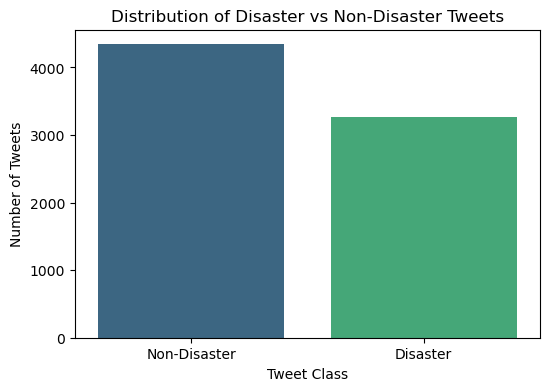

In [9]:
# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="target", palette="viridis")

plt.title("Distribution of Disaster vs Non-Disaster Tweets")
plt.xlabel("Tweet Class")
plt.ylabel("Number of Tweets")
plt.xticks([0, 1], ["Non-Disaster", "Disaster"])

plt.show()

C:\Users\saket\AppData\Local\Temp\ipykernel_18728\2884399930.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_keywords.values, y=top_keywords.index, palette="magma")


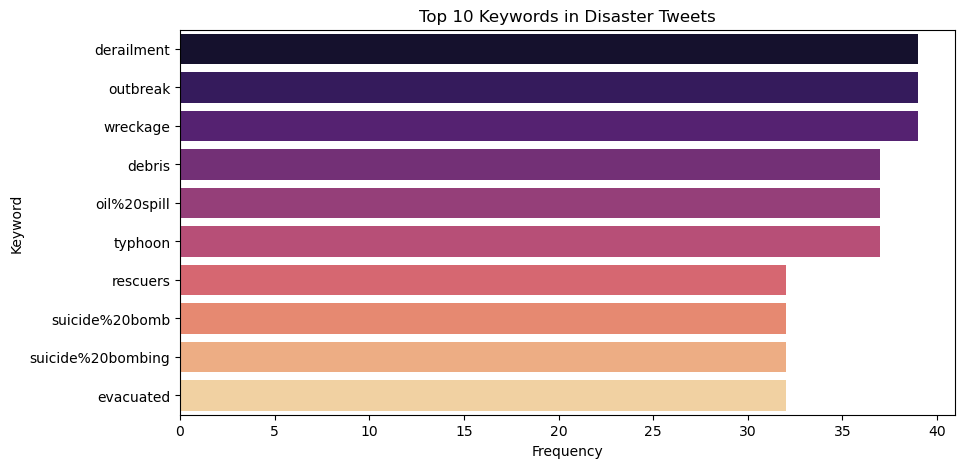

In [10]:
# Top 10 Keywords in Disaster Tweets
top_keywords = (
    df[df["target"] == 1]["keyword"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_keywords.values, y=top_keywords.index, palette="magma")

plt.title("Top 10 Keywords in Disaster Tweets")
plt.xlabel("Frequency")
plt.ylabel("Keyword")

plt.show()

C:\Users\saket\AppData\Local\Temp\ipykernel_18728\3210965146.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=words_df, x="Count", y="Word", palette="rocket")


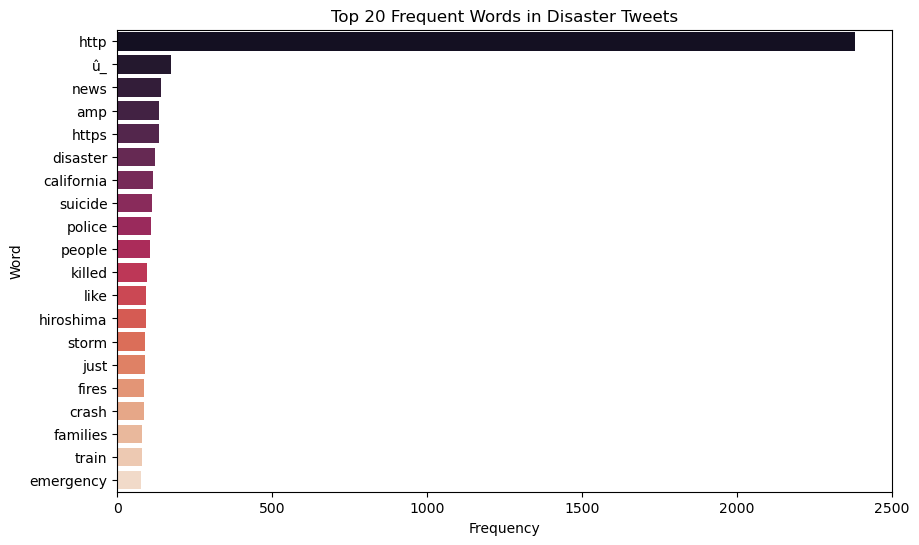

In [11]:
# Select only disaster tweets
disaster_text = df[df["target"] == 1]["text"]

# Extract top words
vectorizer = CountVectorizer(stop_words="english", max_features=20)
X = vectorizer.fit_transform(disaster_text)

word_counts = X.toarray().sum(axis=0)

words_df = (
    pd.DataFrame({
        "Word": vectorizer.get_feature_names_out(),
        "Count": word_counts
    })
    .sort_values(by="Count", ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(data=words_df, x="Count", y="Word", palette="rocket")

plt.title("Top 20 Frequent Words in Disaster Tweets")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

### ***Clean the Text Data***

***(Removing URLs, Special Characters, Punctuation)***

In [12]:
# Function to clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()   # Extra spaces remove
    return text

# Apply cleaning
df["clean_text"] = df["text"].apply(clean_text)

# Display cleaned text
df[["text","clean_text"]].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


### Tokenize the Text

In [13]:
df["tokens"] = df["clean_text"].apply(word_tokenize)

df[["clean_text","tokens"]].head()

,clean_text,tokens
0,our deeds are the reason of this earthquake ma...,"[our, deeds, are, the, reason, of, this, earth..."
1,forest fire near la ronge sask canada,"[forest, fire, near, la, ronge, sask, canada]"
2,all residents asked to shelter in place are be...,"[all, residents, asked, to, shelter, in, place..."
3,people receive wildfires evacuation orders in ...,"[people, receive, wildfires, evacuation, order..."
4,just got sent this photo from ruby alaska as s...,"[just, got, sent, this, photo, from, ruby, ala..."


In [14]:
print("Unique Target Labels:")
print(df["target"].unique())

print("\nTarget Distribution:")
print(df["target"].value_counts())

Unique Target Labels:
[1 0]

Target Distribution:
target
0    4342
1    3271
Name: count, dtype: int64


### Split Dataset into Training and Testing Sets

In [15]:
X = df["clean_text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (6090,)
Testing Data Shape  : (1523,)


# Feature Engineering and Model Selection 

### Word Frequency (CountVectorizer)

In [16]:
count_vectorizer = CountVectorizer(max_features=5000)

X_count = count_vectorizer.fit_transform(df["clean_text"])

print("Count Vectorizer Shape:", X_count.shape)

Count Vectorizer Shape: (7613, 5000)


### TF-IDF Features

In [17]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df["clean_text"])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (7613, 5000)


In [18]:
df["sentiment"] = df["clean_text"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

df[["clean_text","sentiment"]].head()

,clean_text,sentiment
0,our deeds are the reason of this earthquake ma...,0.00000
1,forest fire near la ronge sask canada,0.10000
2,all residents asked to shelter in place are be...,-0.01875
3,people receive wildfires evacuation orders in ...,0.00000
4,just got sent this photo from ruby alaska as s...,0.00000


### Tweet Length

In [19]:
df["tweet_length"] = df["text"].apply(len)

df[["text","tweet_length"]].head()

,text,tweet_length
0,Our Deeds are the Reason of this #earthquake M...,69
1,Forest fire near La Ronge Sask. Canada,38
2,All residents asked to 'shelter in place' are ...,133
3,"13,000 people receive #wildfires evacuation or...",65
4,Just got sent this photo from Ruby #Alaska as ...,88


### Number of Hashtags

In [20]:
df["hashtags"] = df["text"].str.count("#")

df[["text","hashtags"]].head()

,text,hashtags
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,0
2,All residents asked to 'shelter in place' are ...,0
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,2


### Number of User Mentions

In [21]:
df["mentions"] = df["text"].str.count("@")

df[["text","mentions"]].head()

,text,mentions
0,Our Deeds are the Reason of this #earthquake M...,0
1,Forest fire near La Ronge Sask. Canada,0
2,All residents asked to 'shelter in place' are ...,0
3,"13,000 people receive #wildfires evacuation or...",0
4,Just got sent this photo from Ruby #Alaska as ...,0


### Train Word2Vec Model

In [22]:
# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=df["tokens"],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

In [23]:
print("Vocabulary Size:", len(word2vec_model.wv))

Vocabulary Size: 6309


In [24]:
word2vec_model.wv["fire"]

array([-0.19892558,  0.06095439, -0.26010248, -0.11056916,  0.04872968,
       -0.3444066 ,  0.1407429 ,  0.31652027,  0.06769827, -0.07575354,
       -0.05485145, -0.08403098, -0.25494272,  0.31160626,  0.03965835,
       -0.06909358,  0.21656728, -0.21728371, -0.04842152, -0.46873182,
        0.17518583,  0.04968603,  0.11115471, -0.2646419 ,  0.04252001,
       -0.15614876, -0.07609057,  0.16939135, -0.28149682, -0.12849814,
        0.42170477,  0.03943577,  0.02476082, -0.18516508, -0.09505352,
        0.12793311,  0.09155485, -0.20897165,  0.05847192, -0.04110565,
        0.19481339, -0.07423177, -0.05235215, -0.11645506, -0.03214683,
       -0.21380155, -0.3294645 ,  0.0967711 ,  0.11148901,  0.16125824,
        0.11555734, -0.06307253, -0.06381281,  0.09699086, -0.07392185,
        0.2191546 ,  0.0881374 ,  0.1624917 , -0.18793264,  0.18101224,
        0.23550828,  0.04305336, -0.00119501, -0.12199989, -0.16053168,
        0.12347008,  0.23152299,  0.08045776, -0.33865383,  0.12

In [25]:
word2vec_model.wv.most_similar("fire", topn=10)

[('forest', 0.9280908703804016),
 ('rubble', 0.9101725220680237),
 ('part', 0.9053696990013123),
 ('buildings', 0.9049400091171265),
 ('bodies', 0.9028284549713135),
 ('searching', 0.902461588382721),
 ('truck', 0.9004879593849182),
 ('wild', 0.900149405002594),
 ('died', 0.8988641500473022),
 ('alarm', 0.8977840542793274)]

In [26]:
X = X_tfidf
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [28]:
#Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [29]:
#Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Cross Validation

In [30]:
#Logistic Regression
lr_cv = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("LR CV Accuracy:", lr_cv.mean())

LR CV Accuracy: 0.7954022988505748


In [31]:
#Naive Bayes
nb_cv = cross_val_score(
    nb,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("NB CV Accuracy:", nb_cv.mean())

NB CV Accuracy: 0.7922824302134648


In [32]:
#Random Forest
rf_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("RF CV Accuracy:", rf_cv.mean())

RF CV Accuracy: 0.7807881773399016


In [33]:
#Logistic Regression
param_grid = {
    "C":[0.1,1,10],
    "solver":["liblinear","lbfgs"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_lr.fit(X_train,y_train)

print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'C': 1, 'solver': 'liblinear'}
0.7957307060755336


In [39]:
#Random Forest
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': None, 'n_estimators': 100}
0.7807881773399016


## Model Evaluation and Validation 

In [40]:
# Predictions
lr_pred = lr.predict(X_test)

nb_pred = nb.predict(X_test)

rf_pred = rf.predict(X_test)

In [41]:
# Evaluation Metrics
models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("="*50)
    print(name)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy : 0.8207485226526592
Precision: 0.8482632541133455
Recall   : 0.709480122324159
F1 Score : 0.7726894254787677

Classification Report

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       869
           1       0.85      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.81      1523
weighted avg       0.82      0.82      0.82      1523

Naive Bayes
Accuracy : 0.81483913328956
Precision: 0.8618677042801557
Recall   : 0.6773700305810397
F1 Score : 0.7585616438356164

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       869
           1       0.86      0.68      0.76       654

    accuracy                           0.81      1523
   macro avg       0.83      0.80      0.80      1523
weighted avg       0.82      0.81      0.81      1523

Random Forest
Accuracy : 0.79

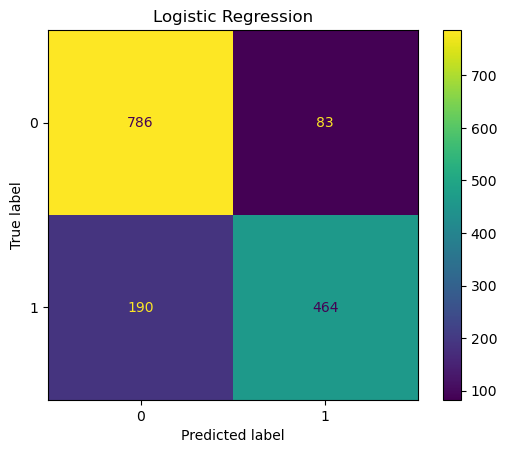

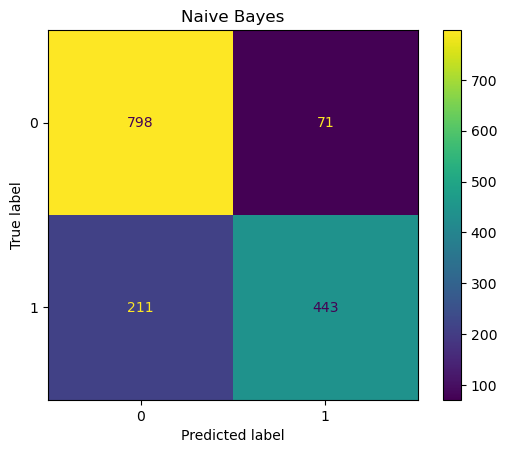

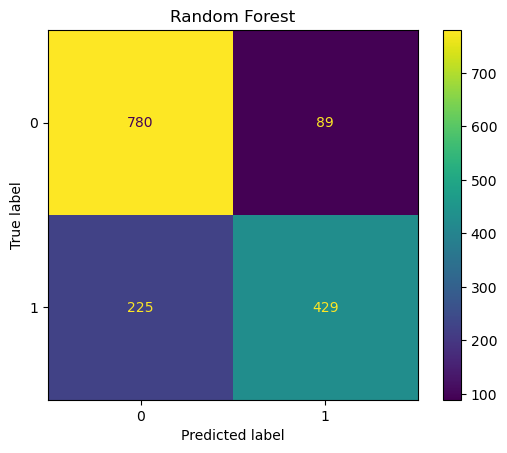

In [42]:
# Confusion Matrix
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()

    plt.title(name)

    plt.show()

<Figure size 800x600 with 0 Axes>

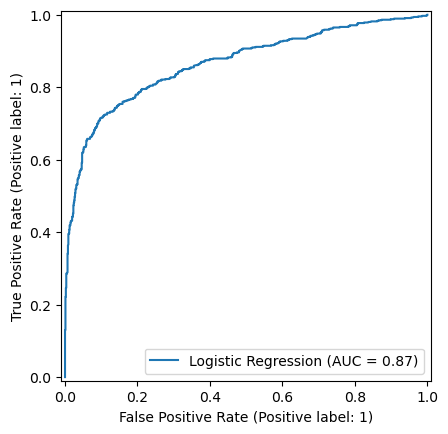

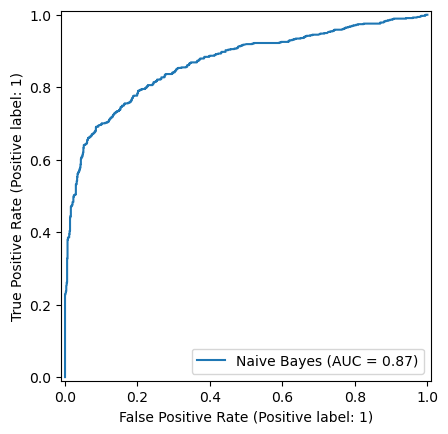

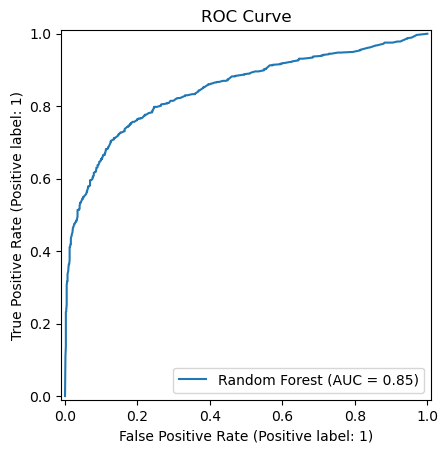

In [45]:
# ROC Curve
plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    nb,
    X_test,
    y_test,
    name="Naive Bayes"
)

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    name="Random Forest"
)

plt.title("ROC Curve")

plt.show()

<Figure size 800x600 with 0 Axes>

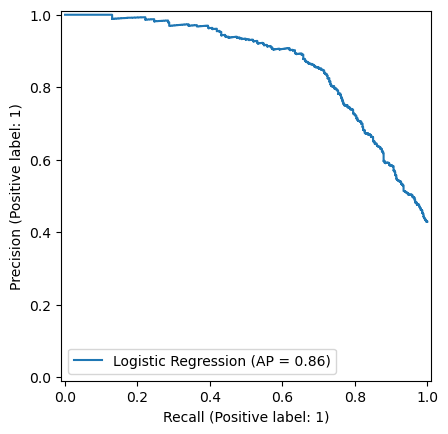

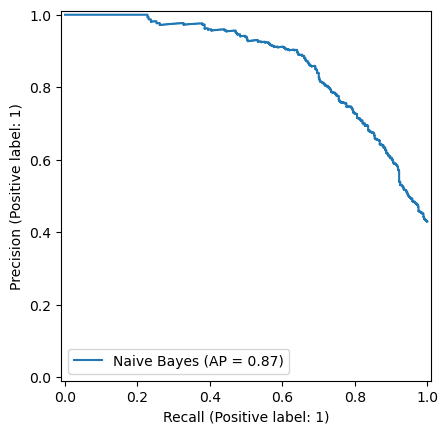

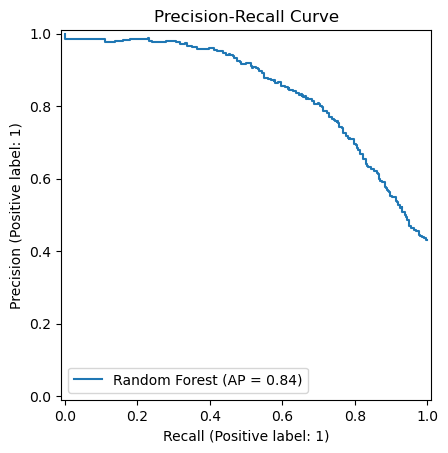

In [46]:
# Precision-Recall Curve
plt.figure(figsize=(8,6))

PrecisionRecallDisplay.from_estimator(
    lr,
    X_test,
    y_test,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_estimator(
    nb,
    X_test,
    y_test,
    name="Naive Bayes"
)

PrecisionRecallDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    name="Random Forest"
)

plt.title("Precision-Recall Curve")

plt.show()

### Compare Models

In [47]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr.predict(X_test)),
        accuracy_score(y_test, nb.predict(X_test)),
        accuracy_score(y_test, rf.predict(X_test))
    ],

    "Precision":[
        precision_score(y_test, lr.predict(X_test)),
        precision_score(y_test, nb.predict(X_test)),
        precision_score(y_test, rf.predict(X_test))
    ],

    "Recall":[
        recall_score(y_test, lr.predict(X_test)),
        recall_score(y_test, nb.predict(X_test)),
        recall_score(y_test, rf.predict(X_test))
    ],

    "F1 Score":[
        f1_score(y_test, lr.predict(X_test)),
        f1_score(y_test, nb.predict(X_test)),
        f1_score(y_test, rf.predict(X_test))
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.820749,0.848263,0.709480,0.772689
1,Naive Bayes,0.814839,0.861868,0.677370,0.758562
2,Random Forest,0.793828,0.828185,0.655963,0.732082


<Figure size 1000x600 with 0 Axes>

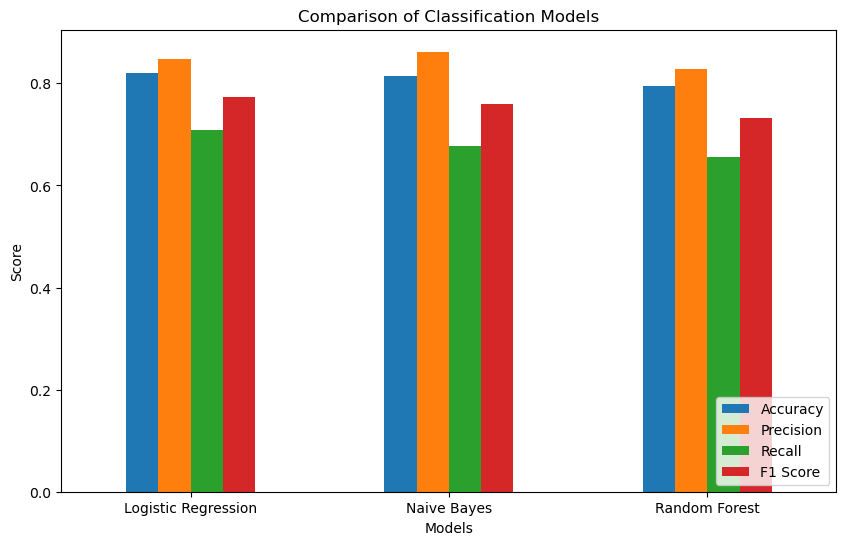

In [53]:
plt.figure(figsize=(10,6))

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

### Model Validation

In [48]:
# Validate Best Model on Test Data
y_pred = lr.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8207485226526592


In [49]:
#Check Overfitting / Underfitting
train_accuracy = lr.score(X_train, y_train)

test_accuracy = lr.score(X_test, y_test)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

Training Accuracy : 0.8702791461412152
Testing Accuracy  : 0.8207485226526592


In [50]:
# Interpretation
if train_accuracy - test_accuracy > 0.05:
    print("Model may be Overfitting")
else:
    print("No significant Overfitting detected")

No significant Overfitting detected


In [51]:
# Generalization Ability
print("Cross Validation Accuracy :", lr_cv.mean())
print("Test Accuracy :", test_accuracy)

Cross Validation Accuracy : 0.7954022988505748
Test Accuracy : 0.8207485226526592


In [52]:
# Validation Summary
print("Model Validation Summary")
print("-" * 40)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Cross Validation  : {lr_cv.mean():.4f}")

if abs(train_accuracy - test_accuracy) < 0.05:
    print("The model generalizes well on unseen data.")
else:
    print("The model may require further tuning.")

Model Validation Summary
----------------------------------------
Training Accuracy : 0.8703
Testing Accuracy  : 0.8207
Cross Validation  : 0.7954
The model generalizes well on unseen data.


In [54]:
import joblib

joblib.dump(lr, "logistic_regression_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [55]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF Saved Successfully")

TF-IDF Saved Successfully
